# TrashNet — Clasificación de residuos con PyTorch

Clasificador CNN para 6 tipos de basura: **cardboard, glass, metal, paper, plastic, trash**.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

Device: cuda
GPU: NVIDIA GeForce GTX 1650 SUPER


In [2]:
BASE_DIR = '../dataset'

TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VALID_DIR = os.path.join(BASE_DIR, 'validation')
TEST_DIR  = os.path.join(BASE_DIR, 'test')

print('Train:', sorted(os.listdir(TRAIN_DIR)))
print('Valid:', sorted(os.listdir(VALID_DIR)))
print('Test:',  sorted(os.listdir(TEST_DIR)))

Train: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Valid: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Test: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [3]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 16

# Augmentation en train (equivalente al ImageDataGenerator de Keras).
# ToTensor() ya reescala a [0,1], equivalente a rescale=1/255.
train_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

eval_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
])

train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
valid_ds = datasets.ImageFolder(VALID_DIR, transform=eval_tf)
test_ds  = datasets.ImageFolder(TEST_DIR,  transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class_names = train_ds.classes
print('Found', len(train_ds), 'train /', len(valid_ds), 'valid /', len(test_ds), 'test images.')
print('Clases (class_indices):', {c: i for i, c in enumerate(class_names)})

Found 1766 train / 377 valid / 384 test images.
Clases (class_indices): {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [4]:
class TrashNet(nn.Module):
    """CNN equivalente al modelo Sequential de Keras.
    Conv(16)->Pool -> Conv(32)->Pool -> Conv(64)->Pool -> Flatten -> Dense(128) -> Dropout(0.3) -> Dense(6).
    Conv 3x3 sin padding (valid): 150->148->74 ->72->36 ->34->17  =>  64*17*17 = 18496 features."""
    def __init__(self, num_classes=6):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 17 * 17, 128), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = TrashNet(num_classes=len(class_names)).to(device)

# CrossEntropyLoss aplica softmax internamente -> la ultima capa es lineal (sin softmax).
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

n_params = sum(p.numel() for p in model.parameters())
print(model)
print('\nParametros entrenables:', f'{n_params:,}')

TrashNet(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=18496, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=6, bias=True)
  )
)

Parametros entrenables: 2,391,974


In [5]:
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    torch.set_grad_enabled(train)
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        if train:
            optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        if train:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    torch.set_grad_enabled(True)
    return total_loss / total, correct / total

EPOCHS = 5
history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(valid_loader, train=False)
    history['loss'].append(tr_loss); history['accuracy'].append(tr_acc)
    history['val_loss'].append(va_loss); history['val_accuracy'].append(va_acc)
    print(f'Epoca {epoch}/{EPOCHS}  -  loss: {tr_loss:.4f}  acc: {tr_acc:.4f}  |  val_loss: {va_loss:.4f}  val_acc: {va_acc:.4f}')

Epoca 1/5  -  loss: 1.7047  acc: 0.2678  |  val_loss: 1.5611  val_acc: 0.3422
Epoca 2/5  -  loss: 1.5380  acc: 0.3675  |  val_loss: 1.3981  val_acc: 0.3926
Epoca 3/5  -  loss: 1.4243  acc: 0.4202  |  val_loss: 1.3035  val_acc: 0.4456
Epoca 4/5  -  loss: 1.3390  acc: 0.4649  |  val_loss: 1.2335  val_acc: 0.5093
Epoca 5/5  -  loss: 1.3081  acc: 0.4955  |  val_loss: 1.2418  val_acc: 0.5199


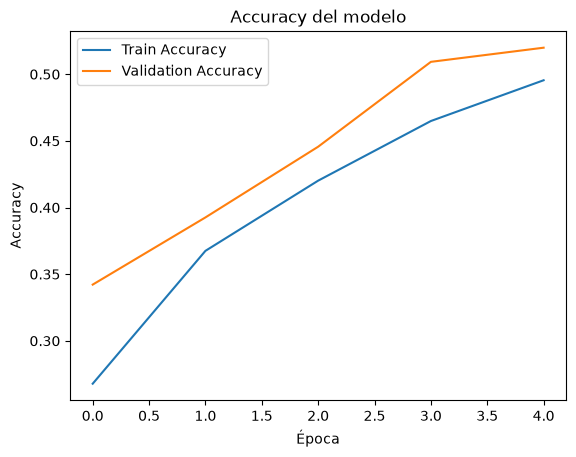

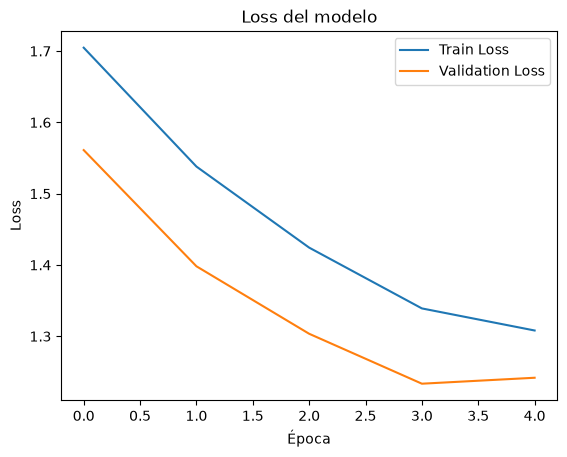

In [6]:
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy del modelo')
plt.xlabel('Época'); plt.ylabel('Accuracy'); plt.legend(); plt.show()

plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss del modelo')
plt.xlabel('Época'); plt.ylabel('Loss'); plt.legend(); plt.show()

In [7]:
test_loss, test_accuracy = run_epoch(test_loader, train=False)
print('Test accuracy:', test_accuracy)
print('Test loss:', test_loss)

Test accuracy: 0.5104166666666666
Test loss: 1.2522856419285138


In [8]:
os.makedirs('modelos', exist_ok=True)
save_path = 'modelos/trashnet_pytorch.pt'
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': class_names,
    'img_size': IMG_SIZE,
}, save_path)
print('Modelo guardado correctamente en', save_path)

Modelo guardado correctamente en modelos/trashnet_pytorch.pt


## Inferencia sobre una imagen nueva

Ejemplo de cómo cargar el modelo guardado y predecir la clase de una imagen (útil para las imágenes de `../imagenes_a_test`).

In [9]:
from PIL import Image

def predecir(ruta_imagen):
    ckpt = torch.load(save_path, map_location=device)
    clf = TrashNet(num_classes=len(ckpt['class_names'])).to(device)
    clf.load_state_dict(ckpt['model_state_dict'])
    clf.eval()
    img = Image.open(ruta_imagen).convert('RGB')
    x = eval_tf(img).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(clf(x), dim=1)[0]
    idx = probs.argmax().item()
    return ckpt['class_names'][idx], probs[idx].item()

# Ejemplo con una imagen del set de test
ejemplo = test_ds.samples[0][0]
clase, conf = predecir(ejemplo)
print(f'Imagen: {ejemplo}')
print(f'Prediccion: {clase}  (confianza {conf:.2%})')

Imagen: ../dataset/test/cardboard/cardboard101.jpg
Prediccion: cardboard  (confianza 67.91%)
